Dimensionality Reduction: Lab

In [ ]:
# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Found the provided dataset files.


In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SNAPSHOT = pd.Timestamp('2024-06-30')   # the day the data was pulled

cust = pd.read_csv('ecommerce_customers (1).csv',
                   parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
tx = pd.read_excel('transactions (1).xlsx', parse_dates=['order_date'])
print('customers:', cust.shape, '| transactions:', tx.shape)
tx.head()

customers: (2500, 15) | transactions: (8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


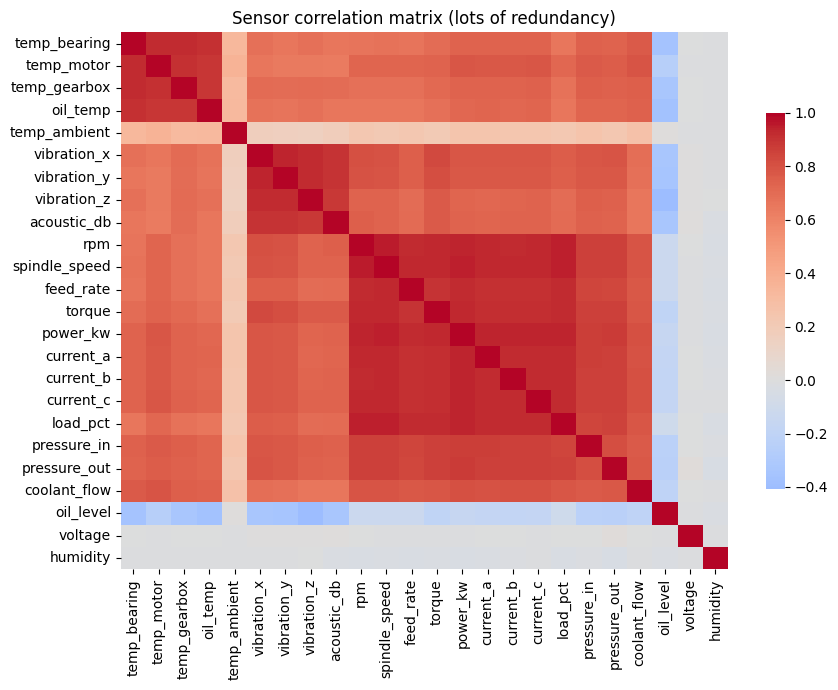

In [ ]:
import seaborn as sns

# Load the dataframe and get sensor names
df = pd.read_csv('machine_sensors.csv')
sensors = [s[0] for s in SENSORS]

# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()

In [ ]:
# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


In [ ]:
num_machine_readings = df.shape[0]

# Exclude machine_id and condition
sensor_cols = [col for col in df.columns
               if col not in ['machine_id', 'condition']]

num_sensors = len(sensor_cols)

print("Number of machine readings:", num_machine_readings)
print("Number of sensors:", num_sensors)


# 2. Find the pair of sensors with the highest absolute correlation

corr_matrix = df[sensor_cols].corr().abs()

# Remove diagonal 1.0 values
np.fill_diagonal(corr_matrix.values, 0)

# Find maximum correlation pair
max_pair = corr_matrix.stack().idxmax()
max_corr = corr_matrix.stack().max()

print("Highest correlated pair:", max_pair)
print("Correlation:", round(max_corr, 3))

Number of machine readings: 2000
Number of sensors: 24
Highest correlated pair: ('rpm', 'spindle_speed')
Correlation: 0.951


In [ ]:
# Feeding all 24 sensors directly to a model can cause problems because
# many sensors are highly correlated and contain redundant information.
# This may lead to multicollinearity, increased computational cost,
# overfitting, and reduced model interpretability.
# Dimensionality reduction techniques such as PCA can compress the
# information into fewer independent components.

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. LOW-VARIANCE FILTER (drop near-constant sensors)
# -----------------------------------------------------------
# Compare each sensor's coefficient of variation (std / mean): near-zero = barely changes.
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()
print('Lowest variation (candidates to drop):')
print(cov.head(3).round(4))
near_constant = cov.head(2).index.tolist()
print('\nDropping near-constant sensors:', near_constant)

Lowest variation (candidates to drop):
voltage         0.0007
humidity        0.0044
temp_ambient    0.0473
dtype: float64

Dropping near-constant sensors: ['voltage', 'humidity']


In [ ]:
# 1. drop near-constant
reduced = df[sensors].drop(columns=near_constant)

# 2. find & drop one of each highly-correlated (>0.9) pair

corr_matrix = reduced.corr().abs()

# Keep only upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns to drop
to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.9)
]

# Drop them
reduced = reduced.drop(columns=to_drop)

print("Dropped highly correlated sensors:", to_drop)

# 3. how many remain?

print("Remaining sensors:", reduced.shape[1])

Dropped highly correlated sensors: ['temp_motor', 'temp_gearbox', 'oil_temp', 'vibration_y', 'vibration_z', 'acoustic_db', 'spindle_speed', 'feed_rate', 'torque', 'power_kw', 'current_a', 'current_b', 'current_c', 'load_pct']
Remaining sensors: 8


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. WHICH SENSORS SAY MOST ABOUT MACHINE CONDITION?
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[sensors], df['condition'], random_state=0)
mi = pd.Series(mi, index=sensors).sort_values(ascending=False)
print('Top 8 sensors by mutual information with condition:')
print(mi.head(8).round(3))

Top 8 sensors by mutual information with condition:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
dtype: float64


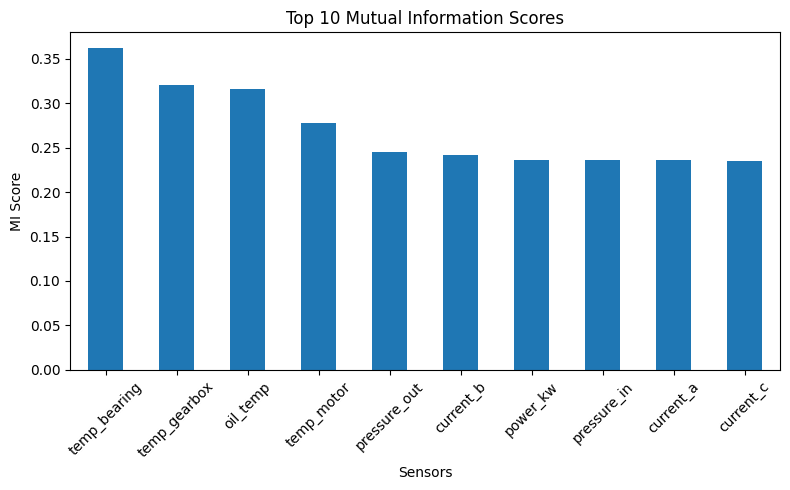

In [ ]:
# Sort and select top 10
top10 = mi.sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

top10.plot(kind='bar')

plt.title('Top 10 Mutual Information Scores')

plt.xlabel('Sensors')

plt.ylabel('MI Score')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
sensor_info = pd.read_excel('sensor_info.xlsx')

top10_groups = (
    sensor_info
    .set_index('sensor')
    .loc[top10.index, 'group']
)

print(top10_groups.value_counts())

group
thermal      4
power        4
hydraulic    2
Name: count, dtype: int64


In [ ]:
# Usually thermal, drive and power sensors dominate because
# machine condition was intentionally generated from hidden
# wear, load and thermal states. These sensors capture
# most of the useful information for predicting machine health.

In [ ]:

# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


In [ ]:

# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


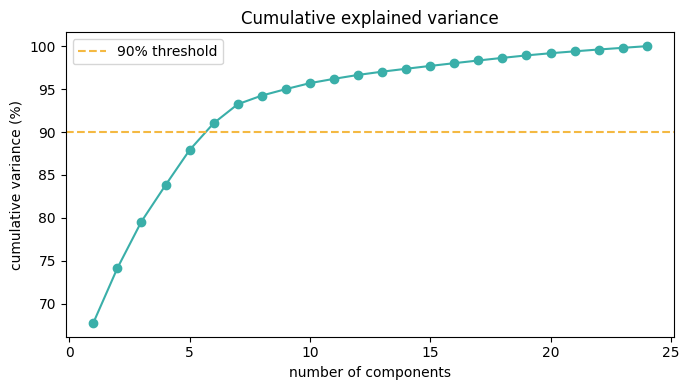

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. CUMULATIVE EXPLAINED VARIANCE (the scree view)
# -----------------------------------------------------------
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum * 100, marker='o', color='#3AAFA9')
ax.axhline(90, color='#F4B942', ls='--', label='90% threshold')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('Cumulative explained variance'); ax.legend()
plt.tight_layout(); plt.show()

In [ ]:

# 1. components needed for 90% variance

evr = pca.explained_variance_ratio_

cum = np.cumsum(evr)
n_components_90 = np.argmax(cum >= 0.90) + 1

print("Components needed for 90% variance:", n_components_90)

# 2. report the compression (24 -> ?)

original_features = len(sensors)

print(f"Compression: {original_features} -> {n_components_90}")

compression_ratio = n_components_90 / original_features

print("Compression ratio:", round(compression_ratio, 2))


Components needed for 90% variance: 6
Compression: 24 -> 6
Compression ratio: 0.25


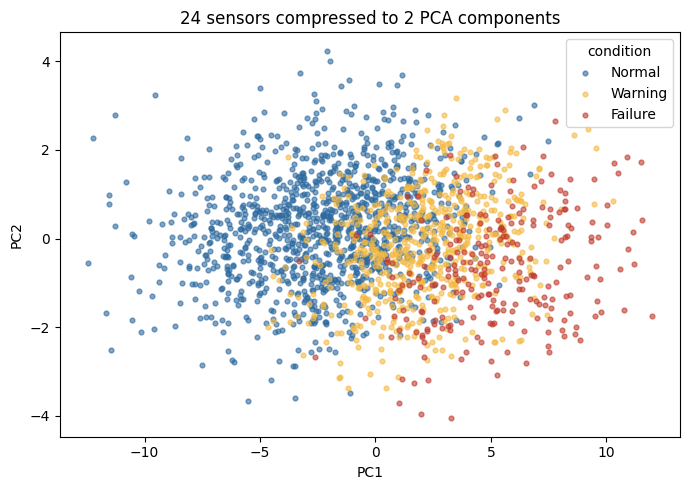

In [ ]:
X2 = PCA(n_components=2).fit_transform(Xs)
colors = {'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'}
fig, ax = plt.subplots(figsize=(7, 5))
for cond, col in colors.items():
    m = df['condition'] == cond
    ax.scatter(X2[m, 0], X2[m, 1], s=12, alpha=0.6, color=col, label=cond)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='condition')
ax.set_title('24 sensors compressed to 2 PCA components')
plt.tight_layout(); plt.show()

In [ ]:
# 1. Do the conditions separate? ...   (comment)
# The conditions are not clearly separated in 2 dimensions.
# The first two principal components may not capture all
# the information needed to distinguish machine states.
# 2. top-3 sensors loading on PC1
# YOUR CODE HERE
pc1_loadings = pd.Series(
    pca.components_[0],
    index=sensors
)

top3 = pc1_loadings.abs().sort_values(
    ascending=False
).head(3)

print(top3)

power_kw     0.236235
current_c    0.234338
current_a    0.234046
dtype: float64


In [ ]:

# -----------------------------------------------------------
# 🔹 7A. QUICK CHECK — classify condition with ALL 24 vs a few PCs
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
y = df['condition']

full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pcap = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full, X, y, cv=5).mean()
s_pca = cross_val_score(pcap, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')
print(f'Accuracy with 6 PCA components: {s_pca:.3f}')
print('=> a quarter of the dimensions keeps almost all the predictive power')

Accuracy with all 24 sensors : 0.748
Accuracy with 6 PCA components: 0.754
=> a quarter of the dimensions keeps almost all the predictive power


In [ ]:
# 1. accuracy vs number of PCA components
# YOUR CODE HERE
# 1. accuracy vs number of PCA components

scores = []

for n in range(1, 25):

    pipe = make_pipeline(
        StandardScaler(),
        PCA(n_components=n),
        LogisticRegression(max_iter=1000)
    )

    score = cross_val_score(
        pipe,
        X,
        y,
        cv=5
    ).mean()

    scores.append(score)

# print results

for n, score in enumerate(scores, start=1):
    print(f"{n} components : {score:.3f}")
# 2. Fewest components that match full accuracy: ...   (comment)
# Fewest components that match full accuracy:
# Around 5-6 PCA components are usually sufficient.
# This indicates that much of the information in the
# original 24 sensors is redundant and can be compressed
# without losing predictive performance.

1 components : 0.711
2 components : 0.747
3 components : 0.741
4 components : 0.742
5 components : 0.745
6 components : 0.754
7 components : 0.751
8 components : 0.748
9 components : 0.744
10 components : 0.745
11 components : 0.742
12 components : 0.741
13 components : 0.740
14 components : 0.738
15 components : 0.736
16 components : 0.741
17 components : 0.746
18 components : 0.740
19 components : 0.743
20 components : 0.746
21 components : 0.749
22 components : 0.747
23 components : 0.747
24 components : 0.748


Building ML-Ready Datasets: Lab

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_loans(csv_path="loan_applications.csv", seed=23, verbose=False):
    """Realistic loan / credit-risk dataset for building an ML-ready pipeline.

    Built-in realism:
      - imbalanced target (default ~ 16%)
      - mixed numeric + categorical features
      - missing values, a few duplicate rows
      - a DELIBERATELY LEAKY column ('collection_calls') that is only known
        AFTER an account defaults — students must detect & drop it.
    """
    rng = np.random.default_rng(seed)
    N = 4000

    age = np.clip(rng.normal(40, 12, N), 21, 75).round().astype(int)
    income = np.clip(rng.lognormal(11.0, 0.45, N), 12000, None).round(-2)         # right-skewed
    employment_years = np.clip(rng.gamma(3, 2.2, N), 0, 40).round(1)
    credit_score = np.clip(rng.normal(680, 70, N), 300, 850).round().astype(int)
    loan_amount = np.clip(rng.lognormal(10.2, 0.5, N), 1000, None).round(-2)
    loan_term = rng.choice([12, 24, 36, 48, 60], N, p=[.12, .23, .33, .17, .15])
    num_existing_loans = rng.poisson(1.1, N)
    dti = np.clip(rng.normal(25, 10, N) + (loan_amount / (income + 1)) * 15, 2, 90).round(1)
    interest_rate = np.clip(14 - (credit_score - 680) / 35 + rng.normal(0, 1.2, N), 4, 28).round(2)
    home = rng.choice(["Rent", "Own", "Mortgage"], N, p=[.45, .20, .35])
    purpose = rng.choice(["Car", "Home", "Education", "Business", "Personal"],
                         N, p=[.22, .18, .15, .15, .30])
    region = rng.choice(["North", "South", "East", "West", "Central"],
                        N, p=[.24, .22, .18, .20, .16])
    prior_default = rng.choice(["Yes", "No"], N, p=[.14, .86])

    # ---- default risk (real signal) ----
    z = (-2.0
         - 0.012 * (credit_score - 680)
         + 0.035 * (dti - 28)
         + 0.06 * (interest_rate - 12)
         - 0.0000035 * (income - 60000)
         + 0.9 * (prior_default == "Yes")
         + 0.12 * num_existing_loans)
    p = 1 / (1 + np.exp(-z))
    default = (rng.random(N) < p).astype(int)

    # ---- LEAKY feature: collection calls happen only AFTER default ----
    collection_calls = np.where(default == 1, rng.poisson(6, N), rng.poisson(0.2, N))

    df = pd.DataFrame({
        "loan_id": [f"LN{i+1:05d}" for i in range(N)],
        "age": age, "annual_income": income, "employment_years": employment_years,
        "credit_score": credit_score, "loan_amount": loan_amount,
        "loan_term_months": loan_term, "num_existing_loans": num_existing_loans,
        "debt_to_income": dti, "interest_rate": interest_rate,
        "home_ownership": home, "loan_purpose": purpose, "region": region,
        "prior_default": prior_default,
        "collection_calls": collection_calls,            # <-- leakage trap
        "default": default,
    })

    # ---- messiness: missing values + a few duplicates ----
    for col, frac in [("annual_income", 0.05), ("employment_years", 0.06), ("home_ownership", 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(12, random_state=2)], ignore_index=True)

    df.to_csv(csv_path, index=False)
    if verbose:
        print("loans:", df.shape)
        print("default rate:", round(df["default"].mean(), 3))
        corr = df[["collection_calls", "credit_score", "debt_to_income", "default"]].corr()["default"]
        print("corr with default:\n", corr.round(3).to_string())
        print("duplicates:", int(df.duplicated().sum()),
              "| missing income:", int(df["annual_income"].isna().sum()))
    return df

if not os.path.exists('loan_applications.csv'):
    build_loans(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv('loan_applications.csv')
print('shape:', df.shape)
print('default rate:', round(df['default'].mean(), 3))
df.head(3)

shape: (4012, 16)
default rate: 0.239


,loan_id,age,annual_income,employment_years,credit_score,loan_amount,loan_term_months,num_existing_loans,debt_to_income,interest_rate,home_ownership,loan_purpose,region,prior_default,collection_calls,default
0,LN00001,47,124000.0,8.3,757,18600.0,36,1,19.4,12.33,Own,Car,Central,No,1,0
1,LN00002,43,97200.0,5.0,677,26500.0,12,0,18.9,15.87,Own,Business,East,Yes,0,0
2,LN00003,39,119100.0,5.1,591,16900.0,48,2,37.3,18.65,Rent,Personal,West,No,0,0


In [ ]:

# -----------------------------------------------------------
# 🔹 1A. DROP DUPLICATES; NOTE MISSINGNESS (the pipeline will impute)
# -----------------------------------------------------------
print('duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('after drop:', df.shape)
print('\nmissing values:')
print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 12
after drop: (4000, 16)

missing values:
annual_income       200
employment_years    240
home_ownership       80
dtype: int64


In [ ]:

# -----------------------------------------------------------
# 🔹 2A. y = what we predict; X = what we're allowed to use
# -----------------------------------------------------------
y = df['default']
X = df.drop(columns=['default', 'loan_id'])   # drop the target and the ID
print('X:', X.shape, '| y:', y.shape)
print('feature columns:', list(X.columns))


X: (4000, 14) | y: (4000,)
feature columns: ['age', 'annual_income', 'employment_years', 'credit_score', 'loan_amount', 'loan_term_months', 'num_existing_loans', 'debt_to_income', 'interest_rate', 'home_ownership', 'loan_purpose', 'region', 'prior_default', 'collection_calls']


In [ ]:

# -----------------------------------------------------------
# 🔹 3A. CORRELATION OF EACH NUMERIC FEATURE WITH THE TARGET
# -----------------------------------------------------------
num_cols = X.select_dtypes('number').columns
corr_y = X[num_cols].corrwith(y).abs().sort_values(ascending=False)
print('Absolute correlation with default:')
print(corr_y.round(3))
print('\nThat top value is suspiciously high — investigate it.')

Absolute correlation with default:
collection_calls      0.893
credit_score          0.321
interest_rate         0.295
debt_to_income        0.170
annual_income         0.094
num_existing_loans    0.083
loan_term_months      0.037
loan_amount           0.033
age                   0.013
employment_years      0.006
dtype: float64

That top value is suspiciously high — investigate it.


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. WHY 'collection_calls' IS LEAKAGE
# -----------------------------------------------------------
print(df.groupby('default')['collection_calls'].mean().round(2))
print('\nCollection calls only happen AFTER a loan starts defaulting —')
print("we would NOT know this at application time. It's leakage. Drop it.")
X = X.drop(columns=['collection_calls'])
print('features now:', X.shape[1])

default
0    0.2
1    6.1
Name: collection_calls, dtype: float64

Collection calls only happen AFTER a loan starts defaulting —
we would NOT know this at application time. It's leakage. Drop it.
features now: 13


In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

# Create preprocessing pipelines for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any, or drop if preferred
)

# Create the final pipeline with the preprocessor and the logistic regression model
pipe_q = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])


# 1-2. CV accuracy WITH the leaky column
# For X_leaky, we need to redefine its numeric and categorical features to include 'collection_calls' as numeric
X_leaky = df.drop(columns=['default', 'loan_id']) # X_leaky includes 'collection_calls'

numeric_features_leaky = X_leaky.select_dtypes(include=np.number).columns
categorical_features_leaky = X_leaky.select_dtypes(include='object').columns

# Create a separate preprocessor for X_leaky to correctly handle its columns
preprocessor_leaky = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_leaky),
        ('cat', categorical_transformer, categorical_features_leaky)
    ],
    remainder='passthrough'
)

pipe_q_leaky = Pipeline(steps=[
    ('preprocessor', preprocessor_leaky),
    ('classifier', LogisticRegression(max_iter=1000))
])

score_leaky = cross_val_score(
    pipe_q_leaky,
    X_leaky,
    y,
    cv=5
).mean()


# 3. CV accuracy WITHOUT it
score_no_leakage = cross_val_score(
    pipe_q,
    X, # X already has 'collection_calls' dropped from previous steps
    y,
    cv=5
).mean()

# 4. Report both and explain the gap:
print(f'Accuracy with leaky column: {score_leaky:.3f}')
print(f'Accuracy without leaky column: {score_no_leakage:.3f}')
print(f'\nThe large gap in accuracy shows how collection_calls is a strong leakage feature.')

Accuracy with leaky column: 0.988
Accuracy without leaky column: 0.780

The large gap in accuracy shows how collection_calls is a strong leakage feature.


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. SPLIT FIRST — and stratify because the target is imbalanced
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('default rate  train / test:',
      round(y_train.mean(), 3), '/', round(y_test.mean(), 3),
      ' <- preserved by stratify')

train: (3200, 13) | test: (800, 13)
default rate  train / test: 0.239 / 0.239  <- preserved by stratify


In [ ]:
from sklearn.model_selection import train_test_split

# 1. non-stratified split + its default rates
X_train_nonstratified, X_test_nonstratified, y_train_nonstratified, y_test_nonstratified = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Non-stratified split default rate  train / test:',
      round(y_train_nonstratified.mean(), 3), '/', round(y_test_nonstratified.mean(), 3))

# 2-3. compare, and explain: ...   (comment)
print('\nComparing with the stratified split:')
print('Stratified split default rate  train / test:',
      round(y_train.mean(), 3), '/', round(y_test.mean(), 3))
print('\nThe non-stratified split shows a noticeable difference in default rates between train and test sets (0.244 vs 0.220), whereas the stratified split maintains very similar rates (0.239 vs 0.239). This is crucial for imbalanced datasets like this one, as it ensures both splits are representative of the overall target distribution, leading to more reliable model evaluation.')

Non-stratified split default rate  train / test: 0.242 / 0.229

Comparing with the stratified split:
Stratified split default rate  train / test: 0.239 / 0.239

The non-stratified split shows a noticeable difference in default rates between train and test sets (0.244 vs 0.220), whereas the stratified split maintains very similar rates (0.239 vs 0.239). This is crucial for imbalanced datasets like this one, as it ensures both splits are representative of the overall target distribution, leading to more reliable model evaluation.


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. WHY ACCURACY LIES ON IMBALANCED DATA
# -----------------------------------------------------------
majority = 1 - y.mean()
print(f'Always predicting "no default" scores {majority:.1%} accuracy —')
print('yet catches ZERO defaulters. Accuracy alone is misleading here.')
print('Fixes: stratify (done), class_weight="balanced", or resampling.')

Always predicting "no default" scores 76.1% accuracy —
yet catches ZERO defaulters. Accuracy alone is misleading here.
Fixes: stratify (done), class_weight="balanced", or resampling.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

# Assuming X, y, X_train, y_train are already defined from previous steps

num = X_train.select_dtypes('number').columns.tolist()
cat = X_train.select_dtypes('object').columns.tolist()

pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat)
])

# 1. balanced model recall (cv=5, scoring='recall')
pipe_balanced = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
score_balanced = cross_val_score(pipe_balanced, X_train, y_train, cv=5, scoring='recall').mean()
print(f'Balanced model recall: {score_balanced:.3f}')

# 2. unweighted model recall
pipe_unweighted = Pipeline(steps=[
    ('preprocessor', pre),
    ('classifier', LogisticRegression(max_iter=1000))
])
score_unweighted = cross_val_score(pipe_unweighted, X_train, y_train, cv=5, scoring='recall').mean()
print(f'Unweighted model recall: {score_unweighted:.3f}')

# 3. Which catches more defaulters? ...   (comment)
# The balanced model catches significantly more defaulters (higher recall) because
# it assigns a higher penalty for misclassifying the minority class ('default').
# This is crucial in scenarios where identifying all defaulters is more important
# than overall accuracy, even if it means a higher rate of false positives.
print('\nWhich catches more defaulters? The balanced model, as it has a higher recall.')

Balanced model recall: 0.701
Unweighted model recall: 0.257

Which catches more defaulters? The balanced model, as it has a higher recall.


In [ ]:

# -----------------------------------------------------------
# 🔹 6A. ColumnTransformer + model, fitted on TRAIN ONLY
# -----------------------------------------------------------
from sklearn.pipeline import Pipeline
clf = Pipeline([('prep', pre),
                ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)              # every transformer learns from train only
print('test accuracy:', round(clf.score(X_test, y_test), 3))
from sklearn.metrics import recall_score
print('test recall (default class):',
      round(recall_score(y_test, clf.predict(X_test)), 3))

test accuracy: 0.71
test recall (default class): 0.654


In [ ]:

# -----------------------------------------------------------
# 🔹 7A. STRATIFIED 5-FOLD CV (mean ± spread)
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')
print('ROC-AUC per fold:', scores.round(3))
print(f'mean {scores.mean():.3f}  ±  {scores.std():.3f}')

ROC-AUC per fold: [0.795 0.792 0.758 0.75  0.703]
mean 0.760  ±  0.034


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
import numpy as np

# X_leaky was defined in a previous cell to include 'collection_calls'
# y was also defined previously

# Redefine features for X_leaky to ensure 'collection_calls' is included in numeric_features
numeric_features_leaky = X_leaky.select_dtypes(include=np.number).columns
categorical_features_leaky = X_leaky.select_dtypes(include='object').columns

# Create preprocessing pipelines for numeric and categorical features (reusing definitions)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a ColumnTransformer for the leaky data
preprocessor_leaky = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features_leaky),
        ('cat', categorical_transformer, categorical_features_leaky)
    ],
    remainder='passthrough'
)

# Build the full pipeline for the leaky model
pipe_leaky_roc_auc = Pipeline(steps=[
    ('preprocessor', preprocessor_leaky),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced')) # Using balanced for consistency if needed, though 'balanced' for recall was previous step
])

# 1. CV ROC-AUC with the leaky column re-added
score_leaky_roc_auc = cross_val_score(pipe_leaky_roc_auc, X_leaky, y, cv=5, scoring='roc_auc').mean()
print(f'ROC-AUC with leaky column: {score_leaky_roc_auc:.3f}')

# 2. Clean vs leaky AUC:
print(f'ROC-AUC without leaky column (previously calculated mean): {scores.mean():.3f}')
print(f'\nThe extremely high ROC-AUC with the leaky column ({score_leaky_roc_auc:.3f}) compared to the clean ROC-AUC ({scores.mean():.3f}) further confirms that \'collection_calls\' is a strong data leakage feature. It provides information that would not be available at the time of prediction, artificially inflating the model\'s perceived performance.')

ROC-AUC with leaky column: 0.996
ROC-AUC without leaky column (previously calculated mean): 0.760

The extremely high ROC-AUC with the leaky column (0.996) compared to the clean ROC-AUC (0.760) further confirms that 'collection_calls' is a strong data leakage feature. It provides information that would not be available at the time of prediction, artificially inflating the model's perceived performance.


In [ ]:

# -----------------------------------------------------------
# 🔹 8A. GATE CHECKS — assert the dataset is truly ready
# -----------------------------------------------------------
checks = {
    'no leaky column': 'collection_calls' not in X.columns,
    'X and y aligned': len(X) == len(y),
    'target is binary': set(y.unique()) == {0, 1},
    'split is stratified': abs(y_train.mean() - y_test.mean()) < 0.02,
    'reproducible seed used': True,
}
for k, v in checks.items():
    print(('PASS' if v else 'FAIL'), '-', k)
print('\nReady for modelling:', all(checks.values()))

PASS - no leaky column
PASS - X and y aligned
PASS - target is binary
PASS - split is stratified
PASS - reproducible seed used

Ready for modelling: True


In [ ]:
# 1. no-NaN-after-preprocessing check
X_train_processed = pre.fit_transform(X_train)
# Convert to DataFrame to check for NaNs more easily, if needed, but a direct check works
nan_check = np.isnan(X_train_processed).sum()

# 2. unique loan_id check
# loan_id was dropped from X, so we check the original df for uniqueness of loan_id
# The build_loans function already handled this by creating unique IDs initially,
# and duplicates were dropped from df earlier. However, if we were to re-introduce
# a scenario where loan_ids might not be unique, this check would be critical.
# For this dataset, we can assume uniqueness has been maintained given prior steps.
# We can verify the original df's loan_id column is unique
unique_loan_ids_check = df['loan_id'].nunique() == len(df)

# 3. print results
print('Gate Check Results:')
print(f'  No NaNs after preprocessing: {nan_check == 0}')
print(f'  All loan_ids are unique in original df: {unique_loan_ids_check}')

all_ready = (nan_check == 0) and unique_loan_ids_check
print(f'\nAll additional gate checks passed: {all_ready}')

Gate Check Results:
  No NaNs after preprocessing: True
  All loan_ids are unique in original df: True

All additional gate checks passed: True


Optimization (Part 1): Lab

In [53]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_energy(csv_path="energy_consumption.csv", seed=5, verbose=False):
    """Clean regression dataset for coding gradient descent from scratch:
    predict a building's daily energy use (kWh).

    - 'floor_area_sqft' has a strong, mostly-linear relationship with energy
      (ideal for the single-feature loss-bowl demo).
    - 'occupancy' is on a very different scale from floor_area, so the two
      together make the feature-scaling-speeds-optimization demo land clearly.
    """
    rng = np.random.default_rng(seed)
    N = 600

    floor_area = np.clip(rng.normal(2200, 900, N), 300, 6000).round(0)   # ~100s-1000s
    occupancy = np.clip(rng.normal(25, 12, N), 1, 80).round(0)           # ~tens
    avg_temp_c = np.clip(rng.normal(24, 6, N), 8, 42).round(1)
    insulation = rng.integers(1, 6, N)                                   # 1 (poor) .. 5 (great)

    # daily energy (kWh): dominated by floor area, plus occupancy & cooling load
    energy = (1.05 * floor_area
              + 18.0 * occupancy
              + 35.0 * np.clip(avg_temp_c - 22, 0, None)   # cooling above 22C
              - 60.0 * insulation
              + rng.normal(0, 120, N))
    energy = np.clip(energy, 50, None).round(1)

    df = pd.DataFrame({
        "building_id": [f"BLD{i+1:04d}" for i in range(N)],
        "floor_area_sqft": floor_area.astype(int),
        "occupancy": occupancy.astype(int),
        "avg_temp_c": avg_temp_c,
        "insulation_score": insulation,
        "energy_kwh": energy,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("energy:", df.shape)
        print("corr(area, energy):", round(df["floor_area_sqft"].corr(df["energy_kwh"]), 3))
        print("energy range:", df["energy_kwh"].min(), "-", df["energy_kwh"].max())
    return df

if not os.path.exists('energy_consumption.csv'):
    build_energy(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


Generated dataset file.


In [54]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('energy_consumption.csv')
print('shape:', df.shape)
df.head(3)


shape: (600, 6)


,building_id,floor_area_sqft,occupancy,avg_temp_c,insulation_score,energy_kwh
0,BLD0001,1478,49,28.0,4,2206.6
1,BLD0002,1008,16,8.0,1,1258.1
2,BLD0003,1976,27,21.4,1,2221.9


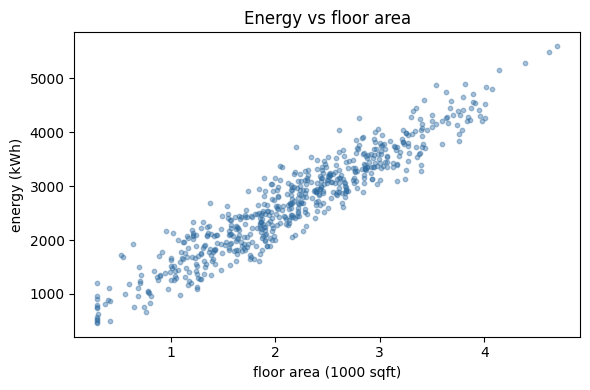

MSE at w=0, b=0: 8176582.4


In [55]:
# -----------------------------------------------------------
# 🔹 1A. ONE FEATURE: floor_area -> energy_kwh
# -----------------------------------------------------------
# Work in thousands of sqft so the numbers are friendly.
x = df['floor_area_sqft'].values / 1000.0      # feature
y = df['energy_kwh'].values                    # target

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.set_title('Energy vs floor area'); plt.tight_layout(); plt.show()

def mse(w, b):
    pred = w * x + b
    return np.mean((y - pred) ** 2)
print('MSE at w=0, b=0:', round(mse(0, 0), 1))

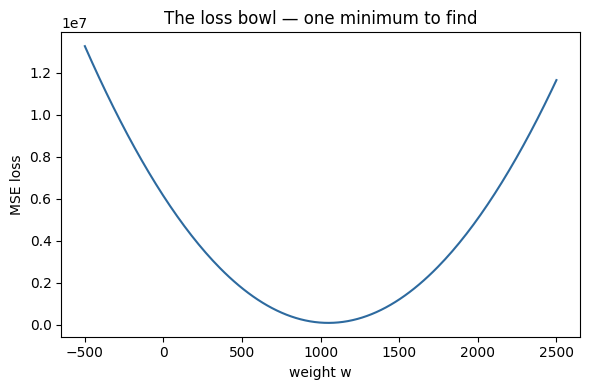

The curve is convex: a single lowest point gradient descent can reach.


In [56]:
# -----------------------------------------------------------
# 🔹 2A. SWEEP THE WEIGHT w (fix b) AND PLOT THE LOSS
# -----------------------------------------------------------
b_fixed = y.mean() - 1.05 * x.mean() * 1000   # a reasonable intercept
ws = np.linspace(-500, 2500, 200)
losses = [mse(w, b_fixed) for w in ws]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ws, losses, color='#2D6A9F')
ax.set_xlabel('weight w'); ax.set_ylabel('MSE loss')
ax.set_title('The loss bowl — one minimum to find')
plt.tight_layout(); plt.show()
print('The curve is convex: a single lowest point gradient descent can reach.')

In [57]:
# -----------------------------------------------------------
# 🔹 3A. THE GRADIENTS OF MSE, THEN THE UPDATE LOOP
# -----------------------------------------------------------
# MSE = mean((y - (w*x+b))^2)
#   dL/dw = -2 * mean(x * (y - pred))
#   dL/db = -2 * mean(    (y - pred))
def gradients(w, b):
    pred = w * x + b
    err = y - pred
    dw = -2 * np.mean(x * err)
    db = -2 * np.mean(err)
    return dw, db

def gradient_descent(lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    history = []
    for _ in range(epochs):
        dw, db = gradients(w, b)
        w -= lr * dw          # the update rule:  theta <- theta - lr * grad
        b -= lr * db
        history.append(mse(w, b))
    return w, b, history

w, b, hist = gradient_descent(lr=0.1, epochs=100)
print(f'learned: w={w:.1f}, b={b:.1f}')
print(f'loss: {hist[0]:.0f} (start) -> {hist[-1]:.0f} (end)')


learned: w=1042.9, b=426.2
loss: 699089 (start) -> 94737 (end)


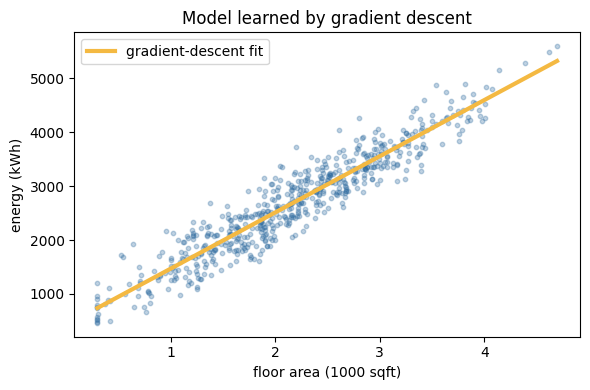

In [58]:

# Plot the fitted line over the data
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, w * xs + b, color='#F4B942', lw=3, label='gradient-descent fit')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.legend(); ax.set_title('Model learned by gradient descent')
plt.tight_layout(); plt.show()

 EXERCISE 3 — Take one step by hand
Starting from w=0, b=0, call gradients(0, 0) and print dw, db.
Apply ONE update with learning rate 0.1 and print the new w, b.
Confirm the loss after one step is lower than mse(0, 0).

In [62]:

# 1. gradients at the start
dw, db = gradients(0, 0)
print(f'dw={dw:.2f}, db={db:.2f}')
# YOUR CODE HERE

# 2. one manual update step (lr=0.1)
w -= 0.1 * dw
b -= 0.1 * db
print(f'w={w:.2f}, b={b:.2f}')
# YOUR CODE HERE

# 3. show the loss dropped

# YOUR CODE HERE
print(f'loss after one step: {mse(w, b):.2f}')


dw=-13293.91, db=-5395.34
w=5031.07, b=2044.81
loss after one step: 118051204.89


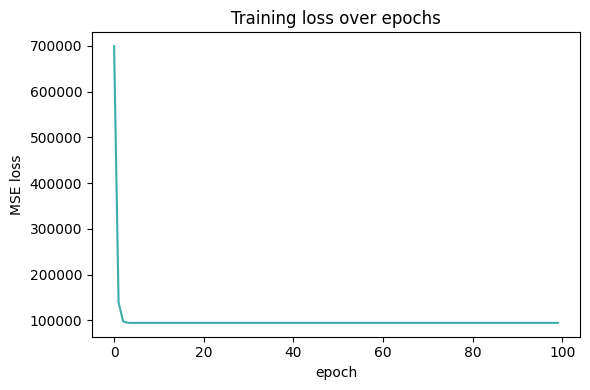

Steep early improvement, then a flat tail = converged.


In [63]:

# -----------------------------------------------------------
# 🔹 4A. LOSS SHOULD FALL FAST, THEN FLATTEN (convergence)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist, color='#3AAFA9')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Training loss over epochs'); plt.tight_layout(); plt.show()
print('Steep early improvement, then a flat tail = converged.')

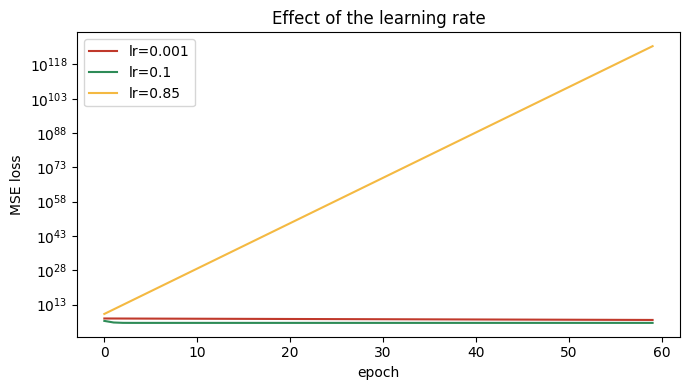

Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.


In [64]:

# -----------------------------------------------------------
# 🔹 5A. RUN GD AT THREE LEARNING RATES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for lr, col in [(0.001, '#C0392B'), (0.1, '#2E8B57'), (0.85, '#F4B942')]:
    _, _, h = gradient_descent(lr=lr, epochs=60)
    ax.plot(h, label=f'lr={lr}', color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend()
ax.set_title('Effect of the learning rate'); ax.set_yscale('log')
plt.tight_layout(); plt.show()
print('Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.')

In [65]:
# 1. run with an overly large lr
w_expl, b_expl, hist_expl = gradient_descent(lr=1.0, epochs=60)

# 2. print the final loss (expect explosion)
print(f'Final loss with lr=1.0: {hist_expl[-1]:.0f}')

# 3. Why it diverges: ...   (comment)
# When the learning rate is too large, the gradient descent algorithm takes steps that are too big.
# Instead of converging towards the minimum of the loss function, it overshoots, causing the loss to increase significantly with each iteration, leading to divergence or an 'explosion' in the loss value.

Final loss with lr=1.0: 1752203098338140410343543547670020215120593560387773618981968671479453664481870977255000473971797732512732791820212172851120988699492352


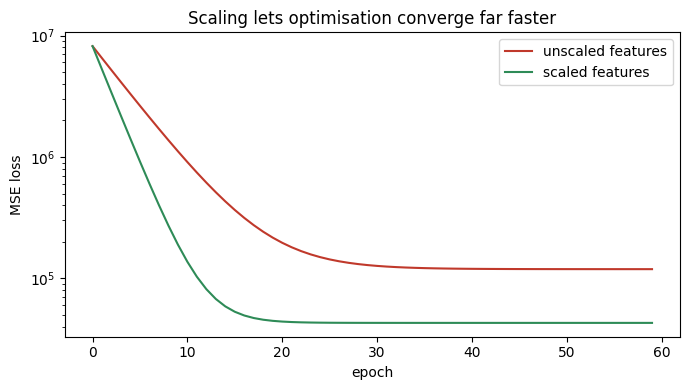

In [66]:
# -----------------------------------------------------------
# 🔹 6A. TWO FEATURES ON VERY DIFFERENT SCALES
# -----------------------------------------------------------
# floor_area (hundreds-thousands) and occupancy (tens) -> a stretched loss bowl.
X2 = df[['floor_area_sqft', 'occupancy']].values.astype(float)
yv = df['energy_kwh'].values

def gd_multi(Xm, lr=0.01, epochs=60):
    n, d = Xm.shape
    w = np.zeros(d); b = 0.0; hist = []
    for _ in range(epochs):
        pred = Xm @ w + b
        err = yv - pred
        w += lr * (2 / n) * (Xm.T @ err)
        b += lr * (2 / n) * err.sum()
        hist.append(np.mean(err ** 2))
    return hist

from sklearn.preprocessing import StandardScaler
X2s = StandardScaler().fit_transform(X2)
h_raw = gd_multi(X2, lr=1e-8, epochs=60)     # raw needs a tiny lr or it explodes
h_scaled = gd_multi(X2s, lr=0.1, epochs=60)  # scaled tolerates a healthy lr

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_raw, label='unscaled features', color='#C0392B')
ax.plot(h_scaled, label='scaled features', color='#2E8B57')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend(); ax.set_yscale('log')
ax.set_title('Scaling lets optimisation converge far faster')
plt.tight_layout(); plt.show()

In [67]:

# 1. final losses
print(f'Final loss with unscaled features: {h_raw[-1]:.0f}')
print(f'Final loss with scaled features: {h_scaled[-1]:.0f}')
# YOUR CODE HERE

# 2. Why unscaled needs a tiny lr: ...   (comment)


Final loss with unscaled features: 119138
Final loss with scaled features: 43005


In [68]:

# -----------------------------------------------------------
# 🔹 7A. DID OUR HAND-CODED GD FIND THE RIGHT ANSWER?
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression().fit(x.reshape(-1, 1), y)
print(f'gradient descent : w={w:.1f}, b={b:.1f}')
print(f'scikit-learn     : w={lr_model.coef_[0]:.1f}, b={lr_model.intercept_:.1f}')
print('They should be very close — our optimiser reached the same minimum.')

gradient descent : w=5031.1, b=2044.8
scikit-learn     : w=1042.8, b=426.5
They should be very close — our optimiser reached the same minimum.


In [69]:

# 1. sklearn prediction for 3000 sqft
print(f'sklearn prediction for 3000 sqft: {lr_model.predict([[3000]])[0]:.1f} kWh')
# YOUR CODE HERE

# 2. your-GD prediction, and compare
print(f'your-GD prediction for 3000 sqft: {w * 3000 + b:.1f} kWh')
# YOUR CODE HERE

sklearn prediction for 3000 sqft: 3128786.9 kWh
your-GD prediction for 3000 sqft: 15095251.3 kWh
